# LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.datasets import load_iris

# IMPORTING DATA

In [3]:
from sklearn.datasets import load_iris
iris=load_iris()

In [4]:
iris.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [5]:
iris.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [6]:
df=pd.DataFrame(iris.data,columns=iris.feature_names)

In [7]:
df['species']=iris.target

In [8]:
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [9]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


# DATA VISULIZATION

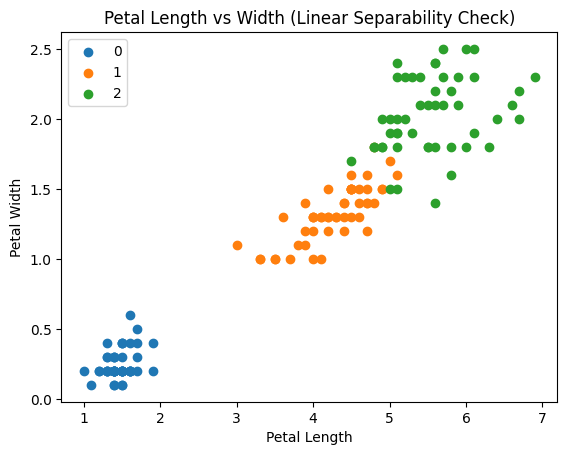

In [10]:
plt.figure()

for name, group in df.groupby("species"):
    plt.scatter(group["petal length (cm)"], group["petal width (cm)"], label=name)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.title("Petal Length vs Width (Linear Separability Check)")
plt.show()

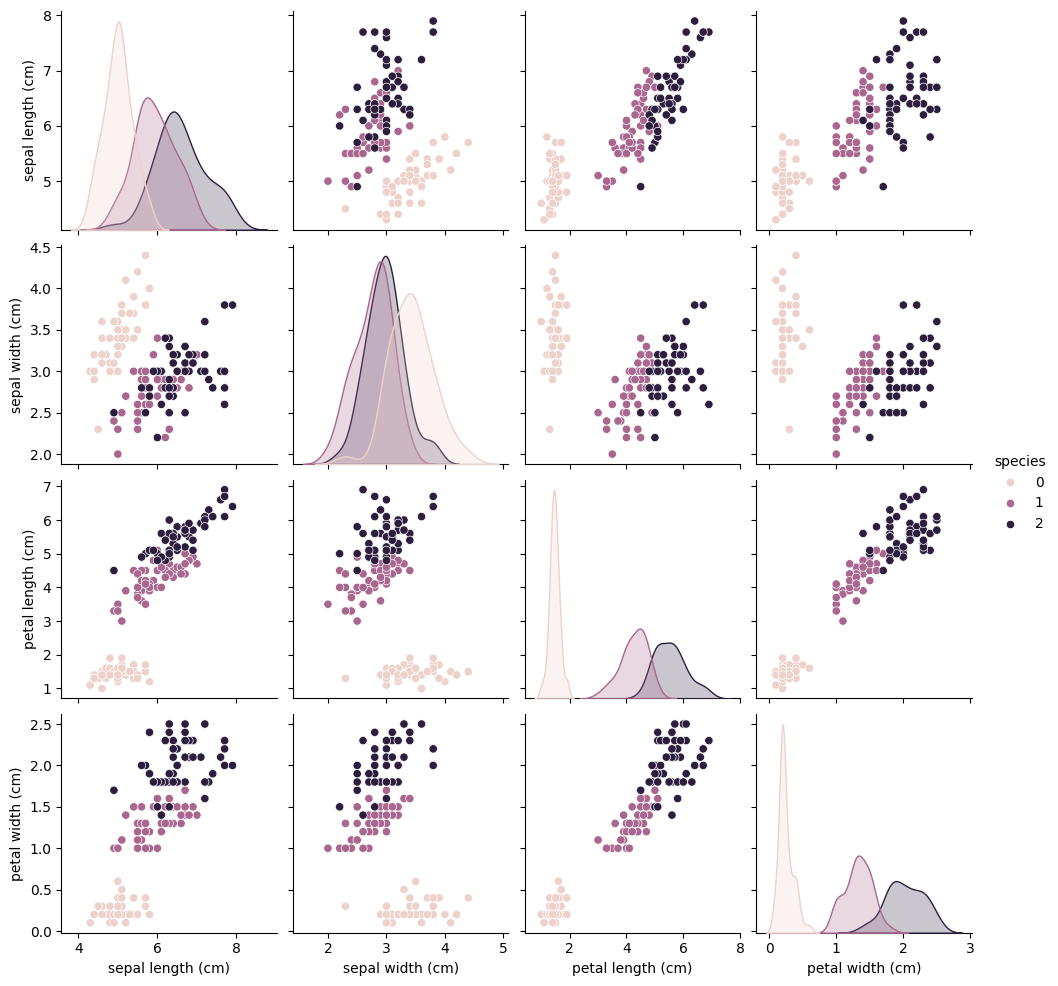

In [11]:
import seaborn as sns

sns.pairplot(df, hue="species")
plt.show()

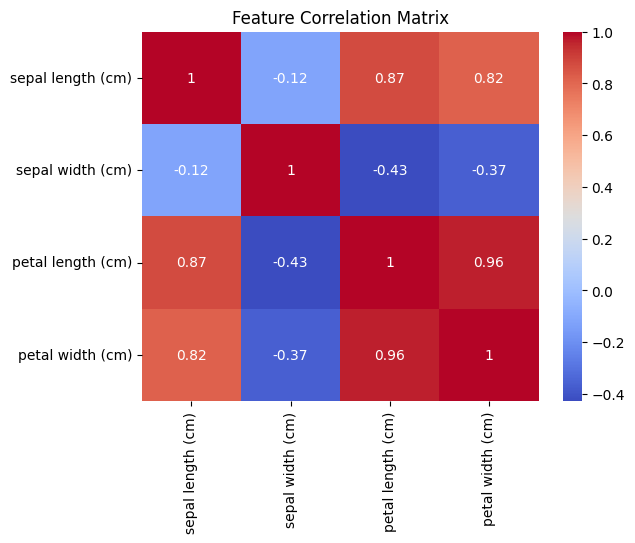

In [12]:
import seaborn as sns

plt.figure()
sns.heatmap(df.iloc[:, :4].corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

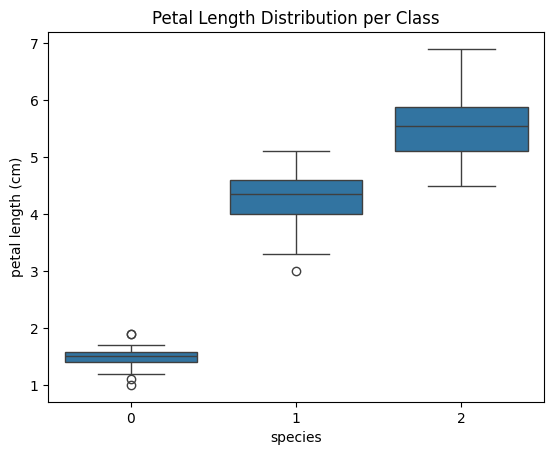

In [13]:
plt.figure()

sns.boxplot(x="species", y="petal length (cm)", data=df)

plt.title("Petal Length Distribution per Class")
plt.show()

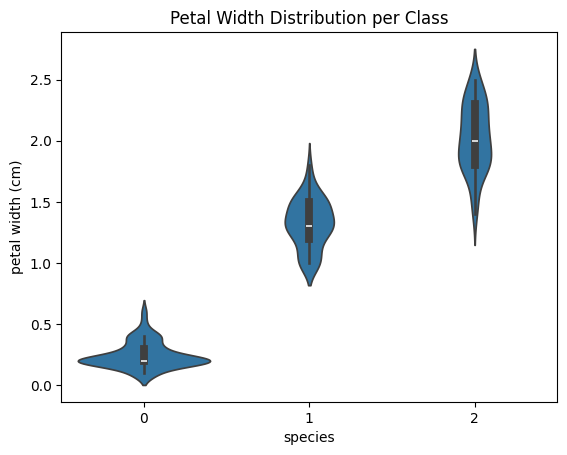

In [14]:
plt.figure()

sns.violinplot(x="species", y="petal width (cm)", data=df)

plt.title("Petal Width Distribution per Class")
plt.show()

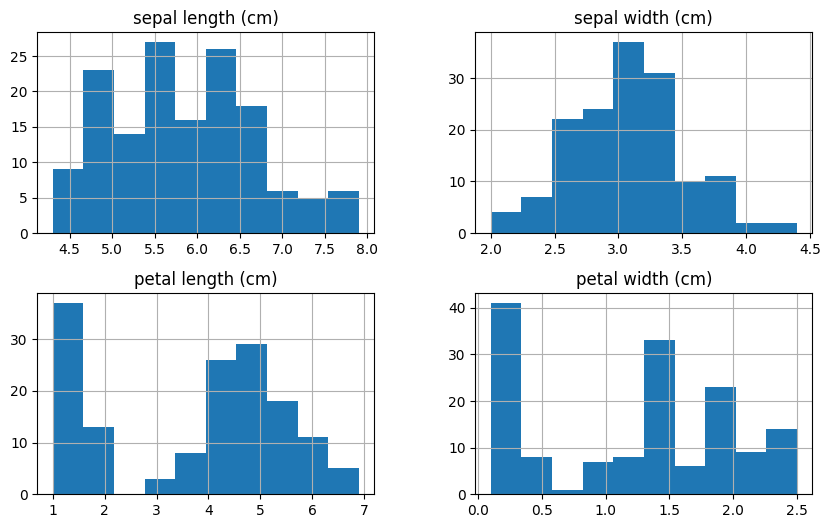

In [15]:
df.iloc[:, :4].hist(figsize=(10, 6))
plt.show()

# Model applying

In [16]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data      # features
y = iris.target    # labels

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [20]:
y_pred = model.predict(X_test)
print(y_pred)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [22]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

iris = load_iris()

model = LogisticRegression(max_iter=200)

scores = cross_val_score(model, iris.data, iris.target, cv=5)
print("Mean accuracy:", scores.mean())

Mean accuracy: 0.9733333333333334


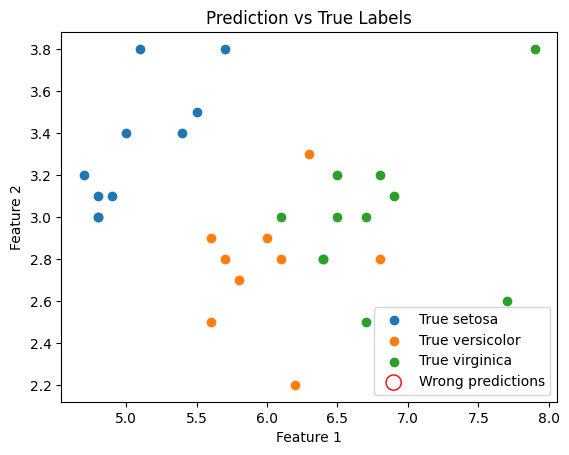

In [23]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

for i in range(3):
    idx = (y_test == i)
    plt.scatter(X_test[idx, 0], X_test[idx, 1], label=f"True {iris.target_names[i]}")

# mark wrong predictions
wrong = y_test != y_pred
plt.scatter(X_test[wrong, 0], X_test[wrong, 1],
            facecolors='none', edgecolors='red', s=120,
            label="Wrong predictions")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Prediction vs True Labels")
plt.legend()
plt.show()